# Analisis NCA + PLS-SEM: Syarat Perlu dan Faktor Penentu Keberhasilan Belajar Daring Mahasiswa Indonesia

**Data:** Global Student Survey COVID-19 gelombang 1 (Aristovnik dkk., 2021), subsampel Indonesia (n = 604).
**Metode:** (1) PLS-SEM untuk logika *sufficiency* (pengaruh); (2) Necessary Condition Analysis (NCA) untuk logika *necessity* (syarat perlu).

Notebook ini **mandiri**: hanya butuh `numpy`, `pandas`, `scipy`, `matplotlib`. PLS-SEM dan NCA diimplementasikan langsung agar setiap langkah bisa diperiksa.

**Cara pakai:** pasang Python (mis. Anaconda) dan jalankan `pip install plspm` sekali untuk validasi. Taruh file `Data_Indonesia_Global_Student_Survey_2020.csv` di folder yang sama dengan notebook ini, lalu jalankan *Run All*.

| Bagian | Isi |
|---|---|
| 1 | Persiapan data dan profil responden |
| 2 | Implementasi PLS-SEM |
| 3 | Model pengukuran (loading, alpha, CR, AVE, HTMT) |
| 4 | Model struktural + bootstrap |
| 5 | Necessary Condition Analysis (effect size, uji permutasi, bottleneck) |
| 6 | Ringkasan: syarat perlu vs pengaruh |
| 6b | Pemeriksaan tambahan: deskriptif, data hilang, *common method bias*, ukuran sampel |
| 7 | Validasi implementasi (uji NCA manual, pembanding paket `plspm`, versi paket) |
| 8 | Ekspor tabel ke Excel |

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import warnings; warnings.filterwarnings('ignore')
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 30)
SEED = 2026
rng = np.random.default_rng(SEED)
import os
FOLDER = r'F:\kuliah daring'   # semua file dibaca dari dan disimpan ke folder ini
if os.path.isdir(FOLDER): os.chdir(FOLDER)
print('Folder kerja:', os.getcwd())
DATA = 'Data_Indonesia_Global_Student_Survey_2020.csv'
N_BOOT = 5000   # jumlah sampel bootstrap PLS-SEM
N_PERM = 10000  # jumlah permutasi NCA

Folder kerja: /tmp/claude-0/nb/work


## 1. Persiapan data

Konstruk mengikuti butir tervalidasi Zou & Zou (2024). Catatan:
- Nilai 1–5; jawaban "tidak berlaku" sudah diubah menjadi kosong.
- **Q20c sudah dibalik** (6 − nilai asli) di file CSV. Namun LO tetap memakai 3 butir (Q20b, Q20d, Q20e), karena versi 4 butir hanya menghasilkan alpha 0,52 pada sampel Indonesia.
- Analisis memakai responden yang lengkap di semua butir (*listwise deletion*), karena PLS-SEM dan NCA membutuhkan data lengkap.

In [2]:
BLOCKS = {
    'TS':  ['Q16b','Q16c','Q16d','Q16e'],                      # dukungan dosen
    'AS':  ['Q19b','Q19c','Q19d','Q19f','Q19g','Q19h','Q19i'],  # dukungan administrasi/institusi
    'SCO': ['Q10a','Q12a'],                                     # kepuasan kuliah sinkron
    'ACO': ['Q10d','Q12d','Q10e','Q12e'],                       # kepuasan kuliah asinkron
    'LT':  ['Q21c','Q21d','Q21f','Q21g'],                       # akses teknologi belajar
    'CS':  ['Q22a','Q22b','Q22c','Q22d','Q22e','Q22f','Q22g'],  # keterampilan komputer
    'WOR': ['Q26d','Q26e','Q26g'],                              # kekhawatiran hidup
    'PAE': ['Q25a','Q25b','Q25c'],                              # emosi akademik positif
    'NAE': ['Q25d','Q25e','Q25f','Q25i'],                       # emosi akademik negatif
    'LO':  ['Q20b','Q20d','Q20e'],                              # hasil belajar (persepsi)
}
LABEL = {'TS':'Dukungan dosen','AS':'Dukungan institusi','SCO':'Kuliah sinkron','ACO':'Kuliah asinkron',
         'LT':'Akses teknologi','CS':'Keterampilan komputer','WOR':'Kekhawatiran hidup',
         'PAE':'Emosi positif','NAE':'Emosi negatif','LO':'Hasil belajar'}
ITEMS = [i for b in BLOCKS.values() for i in b]

raw = pd.read_csv(DATA)
df = raw.dropna(subset=ITEMS).reset_index(drop=True)
print(f'Responden Indonesia: {len(raw)} | lengkap untuk analisis: {len(df)}')

Responden Indonesia: 604 | lengkap untuk analisis: 209


In [3]:
def profil(s, peta):
    v = s.map(peta).fillna('Tidak menjawab')
    t = v.value_counts(); return pd.DataFrame({'n': t, '%': (t/len(s)*100).round(1)})
prof = pd.concat({
    'Jenis kelamin': profil(df.Q8, {1:'Laki-laki',2:'Perempuan',3:'Beragam',4:'Tidak menyebut'}),
    'Jenjang': profil(df.Q5, {1:'S1',2:'S2',3:'S3'}),
    'Status': profil(df.Q4, {1:'Penuh waktu',2:'Paruh waktu'}),
    'Bidang': profil(df.Q6, {1:'Seni & Humaniora',2:'Ilmu Sosial',3:'Ilmu Terapan',4:'Ilmu Alam & Hayati'}),
})
print(f'Usia: rata-rata {df.Q7.mean():.1f} tahun (SD {df.Q7.std():.1f})')
prof

Usia: rata-rata 20.5 tahun (SD 3.7)


n     %
Jenis kelamin Perempuan           153  73.2
              Laki-laki            54  25.8
              Tidak menjawab        1   0.5
              Tidak menyebut        1   0.5
Jenjang       S1                  194  92.8
              S2                    9   4.3
              Tidak menjawab        3   1.4
              S3                    3   1.4
Status        Penuh waktu         167  79.9
              Paruh waktu          40  19.1
              Tidak menjawab        2   1.0
Bidang        Ilmu Sosial         107  51.2
              Ilmu Terapan         37  17.7
              Seni & Humaniora     29  13.9
              Ilmu Alam & Hayati   21  10.0
              Tidak menjawab       15   7.2

## 2. Implementasi PLS-SEM

Algoritma PLS path modeling standar (Lohmöller, 1989; Hair dkk., 2022): outer weights *Mode A*, skema inner *path weighting*, kriteria henti 1e-7. Hasilnya setara dengan pengaturan bawaan SmartPLS.

**Model struktural** (mengikuti logika Zou & Zou, 2024): tujuh faktor lingkungan dan individu → emosi akademik (PAE, NAE) → hasil belajar (LO), ditambah jalur langsung ke LO.

In [4]:
EXO = ['TS','AS','SCO','ACO','LT','CS','WOR']
PATHS = {  # endogen: [prediktor]
    'PAE': EXO,
    'NAE': EXO,
    'LO':  EXO + ['PAE','NAE'],
}
LVS = list(BLOCKS)

def _std(a):
    a = np.asarray(a, float); return (a - a.mean(0)) / a.std(0, ddof=1)

def pls(data, blocks=BLOCKS, paths=PATHS, tol=1e-7, max_iter=300):
    X = {k: _std(data[v].values) for k, v in blocks.items()}
    n = len(data)
    W = {k: np.ones(X[k].shape[1]) for k in blocks}
    pred = {k: paths.get(k, []) for k in blocks}
    succ = {k: [e for e, p in paths.items() if k in p] for k in blocks}
    for it in range(max_iter):
        Y = {k: _std(X[k] @ W[k]) for k in blocks}
        Z = {}
        for k in blocks:
            z = np.zeros(n)
            if pred[k]:
                P = np.column_stack([Y[p] for p in pred[k]])
                b = np.linalg.lstsq(P, Y[k], rcond=None)[0]
                z += P @ b
            for s in succ[k]:
                z += np.corrcoef(Y[k], Y[s])[0, 1] * Y[s]
            Z[k] = _std(z)
        Wn = {}
        for k in blocks:
            w = X[k].T @ Z[k] / (n - 1)
            w = w / np.std(X[k] @ w, ddof=1)
            Wn[k] = w
        diff = max(np.max(np.abs(Wn[k] - W[k])) for k in blocks)
        W = Wn
        if diff < tol: break
    Y = {k: _std(X[k] @ W[k]) for k in blocks}
    # tanda: pastikan mayoritas loading positif
    for k in blocks:
        ld = np.array([np.corrcoef(X[k][:, j], Y[k])[0, 1] for j in range(X[k].shape[1])])
        if (ld < 0).sum() > (ld > 0).sum(): W[k] = -W[k]; Y[k] = -Y[k]
    load = {k: np.array([np.corrcoef(X[k][:, j], Y[k])[0, 1] for j in range(X[k].shape[1])]) for k in blocks}
    beta, r2 = {}, {}
    for e, ps in paths.items():
        P = np.column_stack([Y[p] for p in ps])
        b = np.linalg.lstsq(P, Y[e], rcond=None)[0]
        beta.update({(p, e): bb for p, bb in zip(ps, b)})
        r2[e] = 1 - np.sum((Y[e] - P @ b) ** 2) / np.sum(Y[e] ** 2)
    return dict(W=W, Y=pd.DataFrame(Y), load=load, beta=beta, r2=r2, iter=it + 1)

res = pls(df)
print('Konvergen pada iterasi ke-', res['iter'])

Konvergen pada iterasi ke- 8


## 3. Model pengukuran

Kriteria (Hair dkk., 2022): loading ≥ 0,70 (0,40–0,70 dipertahankan bila AVE dan CR memenuhi); Cronbach's alpha dan CR (rho_c) ≥ 0,70; AVE ≥ 0,50; HTMT < 0,85 (konservatif) atau < 0,90.

In [5]:
rows = []
for k, v in BLOCKS.items():
    for it, l in zip(v, res['load'][k]):
        rows.append({'Konstruk': k, 'Butir': it, 'Loading': round(l, 3)})
tab_loading = pd.DataFrame(rows)

def cronbach(x):
    k = x.shape[1]; return k / (k - 1) * (1 - x.var(ddof=1).sum() / x.sum(1).var(ddof=1))
rel = []
for k, v in BLOCKS.items():
    l = res['load'][k]
    cr = l.sum() ** 2 / (l.sum() ** 2 + (1 - l ** 2).sum())
    w = res['W'][k]; S = np.corrcoef(_std(df[v].values), rowvar=False)
    if len(v) > 1:  # rho_A (Dijkstra & Henseler, 2015)
        ww = np.outer(w, w)
        rho_a = (w @ w) ** 2 * (w @ (S - np.diag(np.diag(S))) @ w) / (w @ (ww - np.diag(np.diag(ww))) @ w)
    else:
        rho_a = 1.0
    rel.append({'Konstruk': k, 'Nama': LABEL[k], 'Butir': len(v),
                'Alpha': round(cronbach(df[v]), 3), 'rho_A': round(rho_a, 3),
                'CR (rho_c)': round(cr, 3), 'AVE': round((l ** 2).mean(), 3),
                'Loading min': round(l.min(), 3)})
tab_rel = pd.DataFrame(rel)
tab_rel['Memenuhi'] = np.where((tab_rel['CR (rho_c)'] >= .70) & (tab_rel.AVE >= .50), 'Ya', 'Periksa')
tab_rel

,Konstruk,Nama,Butir,Alpha,rho_A,CR (rho_c),AVE,Loading min,Memenuhi
0,TS,Dukungan dosen,4,0.792,0.811,0.865,0.615,0.758,Ya
1,AS,Dukungan institusi,7,0.881,0.889,0.909,0.589,0.724,Ya
2,SCO,Kuliah sinkron,2,0.736,0.738,0.884,0.791,0.884,Ya
3,ACO,Kuliah asinkron,4,0.867,0.872,0.910,0.716,0.825,Ya
4,LT,Akses teknologi,4,0.712,0.745,0.822,0.537,0.649,Ya
5,CS,Keterampilan komputer,7,0.869,0.874,0.902,0.570,0.658,Ya
6,WOR,Kekhawatiran hidup,3,0.732,0.748,0.848,0.651,0.757,Ya
7,PAE,Emosi positif,3,0.666,0.686,0.817,0.600,0.685,Ya
8,NAE,Emosi negatif,4,0.800,0.867,0.866,0.619,0.678,Ya
9,LO,Hasil belajar,3,0.720,0.738,0.843,0.643,0.750,Ya


In [6]:
tab_loading[tab_loading.Loading < 0.70]

,Konstruk,Butir,Loading
19,LT,Q21f,0.649
23,CS,Q22c,0.662
24,CS,Q22d,0.658
33,PAE,Q25c,0.685
37,NAE,Q25i,0.678


In [7]:
def htmt(data, blocks):
    R = data[[i for b in blocks.values() for i in b]].corr().abs()
    ks = list(blocks); H = pd.DataFrame(np.nan, index=ks, columns=ks)
    for a in range(len(ks)):
        for b in range(a):
            A, B = blocks[ks[a]], blocks[ks[b]]
            het = R.loc[A, B].values.mean()
            def mono(v):
                if len(v) < 2: return 1.0
                m = R.loc[v, v].values; return m[np.triu_indices(len(v), 1)].mean()
            H.iloc[a, b] = het / np.sqrt(mono(A) * mono(B))
    return H.round(3)
tab_htmt = htmt(df, BLOCKS)
print('HTMT maksimum:', np.nanmax(tab_htmt.values).round(3))
tab_htmt

HTMT maksimum: 0.658


,TS,AS,SCO,ACO,LT,CS,WOR,PAE,NAE,LO
TS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AS,0.490,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCO,0.372,0.528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACO,0.336,0.557,0.658,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LT,0.374,0.367,0.430,0.281,NaN,NaN,NaN,NaN,NaN,NaN
CS,0.533,0.440,0.368,0.366,0.645,NaN,NaN,NaN,NaN,NaN
WOR,0.296,0.155,0.258,0.185,0.329,0.396,NaN,NaN,NaN,NaN
PAE,0.232,0.252,0.328,0.309,0.455,0.282,0.161,NaN,NaN,NaN
NAE,0.100,0.108,0.138,0.071,0.216,0.141,0.277,0.126,NaN,NaN
LO,0.491,0.569,0.526,0.563,0.274,0.362,0.138,0.384,0.12,NaN


In [8]:
# Fornell-Larcker: akar AVE di diagonal harus > korelasi antar-konstruk
C = res['Y'].corr()
fl = C.copy()
for k in LVS: fl.loc[k, k] = np.sqrt((res['load'][k] ** 2).mean())
tab_fl = fl.round(3)
tab_fl

,TS,AS,SCO,ACO,LT,CS,WOR,PAE,NAE,LO
TS,0.784,0.412,0.281,0.285,0.289,0.444,0.223,0.148,0.056,0.384
AS,0.412,0.767,0.423,0.487,0.304,0.378,0.118,0.198,-0.046,0.462
SCO,0.281,0.423,0.890,0.523,0.321,0.303,0.195,0.238,-0.103,0.386
ACO,0.285,0.487,0.523,0.846,0.231,0.320,0.152,0.241,0.009,0.454
LT,0.289,0.304,0.321,0.231,0.733,0.513,0.234,0.330,0.180,0.203
CS,0.444,0.378,0.303,0.320,0.513,0.755,0.322,0.220,0.093,0.299
WOR,0.223,0.118,0.195,0.152,0.234,0.322,0.807,0.083,0.227,0.054
PAE,0.148,0.198,0.238,0.241,0.330,0.220,0.083,0.775,0.028,0.268
NAE,0.056,-0.046,-0.103,0.009,0.180,0.093,0.227,0.028,0.787,-0.088
LO,0.384,0.462,0.386,0.454,0.203,0.299,0.054,0.268,-0.088,0.802


## 4. Model struktural: bootstrap

Bootstrap 5.000 sampel, uji dua arah. **Keputusan signifikansi memakai percentile CI 95%** (tidak memuat nol); nilai t dan p ditampilkan sebagai pelengkap. Juga dihitung VIF inner, f², R², Q² (blindfolding sederhana diganti PLSpredict-lite: *Q²predict* terhadap rata-rata sampel latih, 10-fold).

In [9]:
def boot(data, B=N_BOOT, seed=SEED):
    r = np.random.default_rng(seed); n = len(data); out = []
    for b in range(B):
        idx = r.integers(0, n, n)
        rb = pls(data.iloc[idx].reset_index(drop=True))
        rec = {f'{p}->{e}': v for (p, e), v in rb['beta'].items()}
        for m in EXO:  # efek tidak langsung via emosi
            rec[f'{m}->PAE->LO'] = rb['beta'][(m, 'PAE')] * rb['beta'][('PAE', 'LO')]
            rec[f'{m}->NAE->LO'] = rb['beta'][(m, 'NAE')] * rb['beta'][('NAE', 'LO')]
        out.append(rec)
    return pd.DataFrame(out)

bt = boot(df)
est = {f'{p}->{e}': v for (p, e), v in res['beta'].items()}
for m in EXO:
    est[f'{m}->PAE->LO'] = res['beta'][(m, 'PAE')] * res['beta'][('PAE', 'LO')]
    est[f'{m}->NAE->LO'] = res['beta'][(m, 'NAE')] * res['beta'][('NAE', 'LO')]

def ringkas(keys):
    rows = []
    for k in keys:
        o, sd = est[k], bt[k].std(ddof=1); t = abs(o) / sd
        p = 2 * (1 - stats.t.cdf(t, df=len(bt) - 1))
        lo, hi = np.percentile(bt[k], [2.5, 97.5])
        rows.append({'Jalur': k, 'Koefisien': round(o, 3), 'SD': round(sd, 3), 't': round(t, 2),
                     'p': round(p, 4), 'CI 2.5%': round(lo, 3), 'CI 97.5%': round(hi, 3),
                     'Signifikan': 'Ya' if (lo > 0 or hi < 0) else 'Tidak'})
    return pd.DataFrame(rows)

tab_path = ringkas([f'{p}->{e}' for (p, e) in res['beta']])
tab_path

,Jalur,Koefisien,SD,t,p,CI 2.5%,CI 97.5%,Signifikan
0,TS->PAE,0.002,0.086,0.03,0.9774,-0.176,0.160,Tidak
1,AS->PAE,0.016,0.078,0.21,0.8348,-0.134,0.175,Tidak
2,SCO->PAE,0.076,0.085,0.89,0.3711,-0.097,0.237,Tidak
3,ACO->PAE,0.129,0.094,1.38,0.1685,-0.056,0.308,Tidak
4,LT->PAE,0.265,0.079,3.35,0.0008,0.109,0.424,Ya
5,CS->PAE,0.019,0.097,0.20,0.8416,-0.167,0.211,Tidak
6,WOR->PAE,-0.022,0.085,0.26,0.7946,-0.197,0.136,Tidak
7,TS->NAE,0.032,0.096,0.33,0.7379,-0.151,0.223,Tidak
8,AS->NAE,-0.087,0.084,1.03,0.3016,-0.250,0.079,Tidak
9,SCO->NAE,-0.223,0.084,2.64,0.0082,-0.380,-0.049,Ya


In [10]:
tab_ind = ringkas([k for k in est if k.count('->') == 2])
tab_ind[tab_ind.Signifikan == 'Ya'] if (tab_ind.Signifikan == 'Ya').any() else tab_ind

,Jalur,Koefisien,SD,t,p,CI 2.5%,CI 97.5%,Signifikan
8,LT->PAE->LO,0.035,0.021,1.67,0.0949,0.002,0.084,Ya


In [11]:
Y = res['Y']
# R2, adjusted R2
r2rows = []
for e, ps in PATHS.items():
    n, k = len(Y), len(ps); r2 = res['r2'][e]
    r2rows.append({'Endogen': e, 'Nama': LABEL[e], 'R2': round(r2, 3), 'R2 adj': round(1 - (1 - r2) * (n - 1) / (n - k - 1), 3)})
tab_r2 = pd.DataFrame(r2rows)

# f2 dan VIF inner
def r2_of(e, ps):
    P = Y[ps].values; b = np.linalg.lstsq(P, Y[e].values, rcond=None)[0]
    return 1 - np.sum((Y[e].values - P @ b) ** 2) / np.sum(Y[e].values ** 2)
frows = []
for e, ps in PATHS.items():
    full = res['r2'][e]
    for p in ps:
        others = [q for q in ps if q != p]
        f2 = (full - r2_of(e, others)) / (1 - full)
        vif = 1 / (1 - r2_of(p, others)) if others else 1
        frows.append({'Jalur': f'{p}->{e}', 'f2': round(f2, 3), 'VIF inner': round(vif, 2)})
tab_f2 = pd.DataFrame(frows)
print(tab_r2.to_string(index=False)); print()
print('VIF inner maksimum:', tab_f2['VIF inner'].max())
tab_f2

Endogen          Nama    R2  R2 adj
    PAE Emosi positif 0.143   0.113
    NAE Emosi negatif 0.115   0.084
     LO Hasil belajar 0.353   0.324

VIF inner maksimum: 1.69


,Jalur,f2,VIF inner
0,TS->PAE,0.000,1.39
1,AS->PAE,0.000,1.57
2,SCO->PAE,0.004,1.53
3,ACO->PAE,0.012,1.58
4,LT->PAE,0.057,1.43
5,CS->PAE,0.000,1.69
6,WOR->PAE,0.000,1.15
7,TS->NAE,0.001,1.39
8,AS->NAE,0.005,1.57
9,SCO->NAE,0.037,1.53


In [12]:
# Q2predict (10-fold) untuk indikator LO: dibandingkan prediksi naif rata-rata
def q2predict(data, target='LO', k=10, seed=SEED):
    r = np.random.default_rng(seed); idx = r.permutation(len(data)); folds = np.array_split(idx, k)
    items = BLOCKS[target]; sse_pls = np.zeros(len(items)); sse_naive = np.zeros(len(items))
    for f in folds:
        tr = data.drop(index=f).reset_index(drop=True); te = data.loc[f]
        m = pls(tr)
        # skor LV eksogen di data uji (pakai mean/sd data latih)
        Ypred = {}
        for kk in EXO:
            Xs = (te[BLOCKS[kk]].values - tr[BLOCKS[kk]].values.mean(0)) / tr[BLOCKS[kk]].values.std(0, ddof=1)
            y = Xs @ m['W'][kk]; Ypred[kk] = y
        # propagasi lewat model
        for e in ['PAE', 'NAE']:
            Ypred[e] = sum(m['beta'][(p, e)] * Ypred[p] for p in PATHS[e])
        lo = sum(m['beta'][(p, 'LO')] * Ypred[p] for p in PATHS['LO'])
        for j, it in enumerate(items):
            mu, sd = tr[it].mean(), tr[it].std(ddof=1)
            pred = mu + sd * m['load']['LO'][j] * lo
            sse_pls[j] += np.sum((te[it].values - pred) ** 2)
            sse_naive[j] += np.sum((te[it].values - mu) ** 2)
    return pd.DataFrame({'Butir': items, 'Q2predict': (1 - sse_pls / sse_naive).round(3)})
tab_q2 = q2predict(df)
tab_q2

,Butir,Q2predict
0,Q20b,0.111
1,Q20d,0.222
2,Q20e,0.161


## 5. Necessary Condition Analysis (NCA)

Mengikuti Dul (2016) dan Dul dkk. (2020):
- Skor variabel laten dari PLS-SEM diubah ke skala 0–100 (min–maks), seperti anjuran Richter dkk. (2020) untuk NCA berbasis PLS-SEM.
- Garis plafon **CE-FDH** (step function) dan **CR-FDH** (garis regresi melalui titik-titik puncak CE-FDH).
- **Effect size d** = luas zona kosong di atas plafon ÷ luas ruang lingkup. Kategori: 0 ≤ d < 0,1 kecil; 0,1–0,3 sedang; 0,3–0,5 besar; ≥ 0,5 sangat besar.
- **Uji permutasi** 10.000 kali: syarat perlu diterima bila d ≥ 0,10 **dan** p < 0,05.
- Kekhawatiran (WOR) dan emosi negatif (NAE) dibalik (100 − skor), sehingga yang diuji adalah *rendahnya* kedua kondisi itu.

In [13]:
# Kompatibel untuk numpy lama (np.trapz) dan numpy >= 2.0 (np.trapezoid)
_trapz = getattr(np, 'trapezoid', None) or getattr(np, 'trapz')

def to100(s): s = np.asarray(s, float); return (s - s.min()) / (s.max() - s.min()) * 100

def ce_fdh_peers(x, y):
    o = np.lexsort((-y, x)); xs, ys = x[o], y[o]
    px, py, best = [], [], -np.inf
    for xi, yi in zip(xs, ys):
        if yi > best: px.append(xi); py.append(yi); best = yi
    return np.array(px), np.array(py)

def ceiling_zone_ce(x, y):
    px, py = ce_fdh_peers(x, y); xmax, ymax = x.max(), y.max(); area = 0.0
    for i in range(len(px)):
        x_next = px[i + 1] if i + 1 < len(px) else xmax
        area += (x_next - px[i]) * (ymax - py[i])
    return area

def ceiling_zone_cr(x, y):
    px, py = ce_fdh_peers(x, y)
    if len(px) < 2: return 0.0, (np.nan, np.nan)
    b, a = np.polyfit(px, py, 1)  # y = a + b x
    xmin, xmax, ymin, ymax = x.min(), x.max(), y.min(), y.max()
    g = np.linspace(xmin, xmax, 2001); c = np.clip(a + b * g, ymin, ymax)
    area = _trapz(ymax - c, g)
    return area, (a, b)

def nca(x, y, ceiling='ce'):
    x = np.asarray(x, float); y = np.asarray(y, float)
    scope = (x.max() - x.min()) * (y.max() - y.min())
    z = ceiling_zone_ce(x, y) if ceiling == 'ce' else ceiling_zone_cr(x, y)[0]
    return z / scope

def nca_perm(x, y, B=N_PERM, ceiling='ce', seed=SEED):
    r = np.random.default_rng(seed); d0 = nca(x, y, ceiling)
    dp = np.array([nca(x, r.permutation(y), ceiling) for _ in range(B)])
    return d0, (np.sum(dp >= d0) + 1) / (B + 1)

def accuracy_cr(x, y):
    _, (a, b) = ceiling_zone_cr(x, y)
    return np.mean(y <= a + b * x + 1e-9) * 100

S = pd.DataFrame({k: to100(res['Y'][k]) for k in LVS})
# Kondisi negatif dibalik: yang diuji sebagai syarat adalah RENDAHNYA kekhawatiran dan emosi negatif
for k in ['WOR', 'NAE']: S[k] = 100 - S[k]
LABEL_NCA = {**LABEL, 'WOR': 'Rendahnya kekhawatiran', 'NAE': 'Rendahnya emosi negatif'}
nca_rows = []
for k in EXO + ['PAE', 'NAE']:
    d_ce, p_ce = nca_perm(S[k].values, S['LO'].values, ceiling='ce')
    d_cr, p_cr = nca_perm(S[k].values, S['LO'].values, ceiling='cr')
    kat = lambda d: 'kecil' if d < .1 else 'sedang' if d < .3 else 'besar' if d < .5 else 'sangat besar'
    nca_rows.append({'Kondisi': k, 'Nama': LABEL_NCA[k],
                     'd CE-FDH': round(d_ce, 3), 'p CE-FDH': round(p_ce, 4),
                     'd CR-FDH': round(d_cr, 3), 'p CR-FDH': round(p_cr, 4),
                     'Akurasi CR-FDH (%)': round(accuracy_cr(S[k].values, S['LO'].values), 1),
                     'Kategori (CE)': kat(d_ce),
                     'Syarat perlu?': 'Ya' if (d_ce >= .1 and p_ce < .05) else 'Tidak'})
tab_nca = pd.DataFrame(nca_rows)
tab_nca

,Kondisi,Nama,d CE-FDH,p CE-FDH,d CR-FDH,p CR-FDH,Akurasi CR-FDH (%),Kategori (CE),Syarat perlu?
0,TS,Dukungan dosen,0.421,0.0001,0.359,0.0001,92.3,besar,Ya
1,AS,Dukungan institusi,0.147,0.0276,0.128,0.0418,98.1,sedang,Ya
2,SCO,Kuliah sinkron,0.134,0.0069,0.116,0.0083,98.1,sedang,Ya
3,ACO,Kuliah asinkron,0.162,0.0009,0.151,0.0004,97.6,sedang,Ya
4,LT,Akses teknologi,0.192,0.0016,0.168,0.0057,97.1,sedang,Ya
5,CS,Keterampilan komputer,0.292,0.0001,0.254,0.0001,98.1,sedang,Ya
6,WOR,Rendahnya kekhawatiran,0.020,0.9271,0.013,0.8964,99.0,kecil,Tidak
7,PAE,Emosi positif,0.131,0.0156,0.101,0.0376,98.6,sedang,Ya
8,NAE,Rendahnya emosi negatif,0.089,0.2381,0.085,0.1510,98.1,kecil,Tidak


In [14]:
# Bottleneck table (CE-FDH): tingkat minimum kondisi (% rentang) agar LO mencapai tingkat tertentu
def bottleneck(x, y, levels=range(0, 101, 10)):
    px, py = ce_fdh_peers(x, y); out = []
    for L in levels:
        target = y.min() + L / 100 * (y.max() - y.min())
        ok = px[py >= target - 1e-9]
        need = ok.min() if len(ok) else np.nan
        pct = (need - x.min()) / (x.max() - x.min()) * 100
        out.append('NN' if pct <= 0 else round(pct, 1))
    return out
lv = list(range(0, 101, 10))
tab_bn = pd.DataFrame({'LO (%)': lv})
for k in EXO + ['PAE', 'NAE']:
    tab_bn[k] = bottleneck(S[k].values, S['LO'].values, lv)
print('NN = tidak diperlukan pada tingkat LO tersebut')
tab_bn

NN = tidak diperlukan pada tingkat LO tersebut


,LO (%),TS,AS,SCO,ACO,LT,CS,WOR,PAE,NAE
0,0,NN,NN,NN,NN,NN,NN,NN,NN,NN
1,10,33.4,NN,NN,NN,12.2,14.0,NN,NN,NN
2,20,33.4,NN,NN,NN,12.2,14.0,NN,NN,NN
3,30,34.5,NN,NN,NN,12.2,14.0,NN,NN,NN
4,40,34.5,NN,NN,NN,12.2,14.0,NN,NN,NN
5,50,34.5,NN,NN,NN,12.2,14.0,NN,NN,NN
6,60,42.5,13.3,NN,5.9,12.2,32.2,NN,NN,7.3
7,70,50.0,13.3,25.0,25.0,20.8,43.2,NN,26.7,7.3
8,80,50.0,25.0,25.0,38.5,20.8,47.1,NN,26.7,7.3
9,90,50.0,50.0,50.0,67.4,20.8,68.0,NN,42.5,37.3


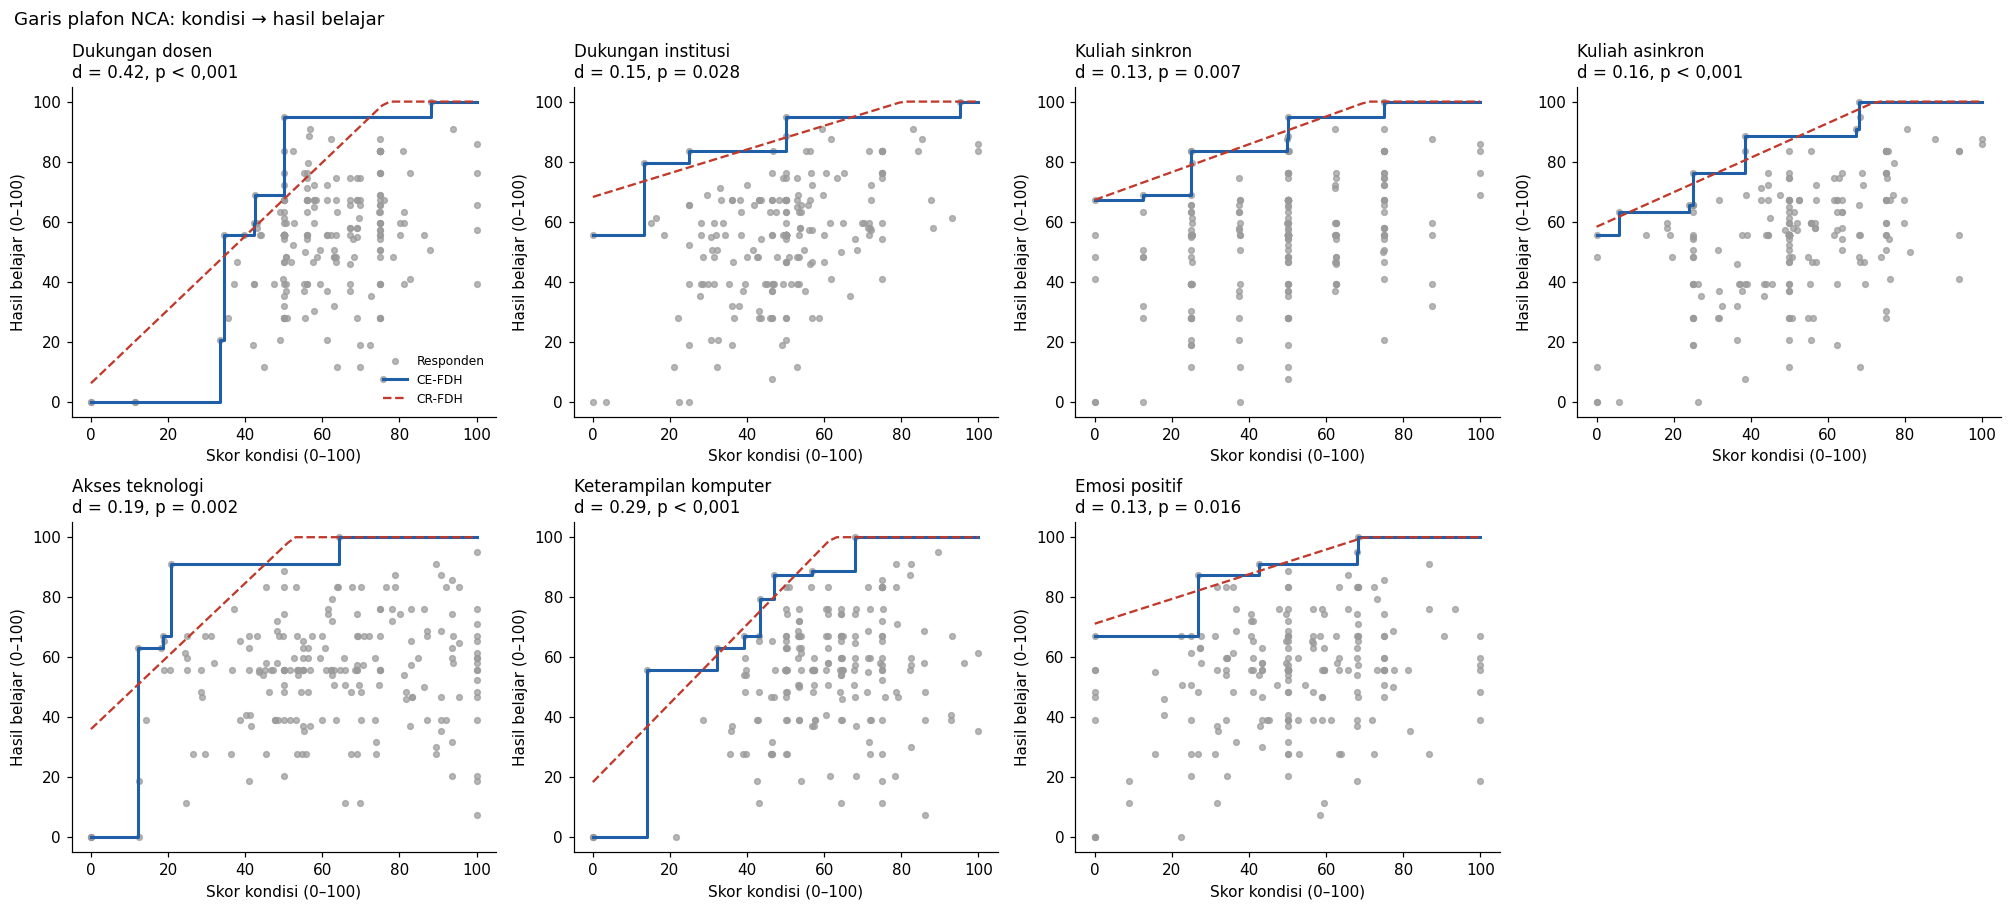

In [15]:
# Plot scatter + garis plafon untuk kondisi yang terbukti perlu
sig = tab_nca.loc[tab_nca['Syarat perlu?'] == 'Ya', 'Kondisi'].tolist() or tab_nca.sort_values('d CE-FDH', ascending=False).Kondisi.head(2).tolist()
ncol = min(4, len(sig)); nrow = int(np.ceil(len(sig) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.6 * ncol, 4.2 * nrow), squeeze=False)
for ax in axes.flat[len(sig):]: ax.axis('off')
for ax, k in zip(axes.flat, sig):
    x, y = S[k].values, S['LO'].values
    ax.scatter(x, y, s=14, color='#9a9a9a', alpha=.7, label='Responden')
    px, py = ce_fdh_peers(x, y)
    sx = np.r_[px, x.max()]; sy = np.r_[py, py[-1]]
    ax.step(sx, sy, where='post', color='#1f5fa8', lw=2, label='CE-FDH')
    _, (a, b) = ceiling_zone_cr(x, y); g = np.linspace(x.min(), x.max(), 50)
    ax.plot(g, np.clip(a + b * g, y.min(), y.max()), '--', color='#c0392b', lw=1.5, label='CR-FDH')
    r = tab_nca.set_index('Kondisi').loc[k]
    ax.set_title(f"{LABEL_NCA[k]}\nd = {r['d CE-FDH']:.2f}, " + ('p < 0,001' if r['p CE-FDH'] < .001 else f"p = {r['p CE-FDH']:.3f}"), fontsize=11, loc='left')
    ax.set_xlabel('Skor kondisi (0–100)'); ax.set_ylabel('Hasil belajar (0–100)')
    for s_ in ['top', 'right']: ax.spines[s_].set_visible(False)
axes.flat[0].legend(frameon=False, fontsize=8, loc='lower right')
fig.suptitle('Garis plafon NCA: kondisi → hasil belajar', x=0.01, ha='left', fontsize=12)
plt.tight_layout(); plt.savefig('Gambar_NCA_plot.png', dpi=200); plt.show()

## 6. Ringkasan: syarat perlu vs pengaruh

Tabel gabungan ini adalah inti temuan artikel. Setiap faktor dikelompokkan menurut dua logika:
- **Perlu dan berpengaruh**: harus ada dan juga menambah hasil belajar. Prioritas utama.
- **Perlu, tidak berpengaruh**: harus mencapai ambang minimum; di atas ambang itu tidak banyak menambah.
- **Berpengaruh, tidak perlu**: menambah hasil belajar, tetapi kekurangannya bisa diimbangi faktor lain.
- **Keduanya tidak**: tidak terbukti.

*Pengaruh* di sini adalah efek total (langsung + tidak langsung) ke LO. Untuk WOR dan NAE, tanda efek dibalik agar searah dengan NCA (rendahnya kekhawatiran/emosi negatif).

In [16]:
tot = {}
for m in EXO:
    tot[m] = bt[f'{m}->LO'] + bt[f'{m}->PAE->LO'] + bt[f'{m}->NAE->LO']
for m in ['PAE', 'NAE']: tot[m] = bt[f'{m}->LO']
rows = []
for k in EXO + ['PAE', 'NAE']:
    o = est[f'{k}->LO'] + (est.get(f'{k}->PAE->LO', 0) + est.get(f'{k}->NAE->LO', 0) if k in EXO else 0)
    sg = -1 if k in ['WOR', 'NAE'] else 1   # disamakan arahnya dengan NCA (rendahnya WOR/NAE)
    o = sg * o
    lo_, hi_ = np.sort(np.percentile(sg * tot[k], [2.5, 97.5])); s_ = lo_ > 0 or hi_ < 0
    n_ = tab_nca.set_index('Kondisi').loc[k]
    perlu = n_['Syarat perlu?'] == 'Ya'
    kel = ('Perlu dan berpengaruh' if perlu and s_ else 'Perlu, tidak berpengaruh' if perlu
           else 'Berpengaruh, tidak perlu' if s_ else 'Keduanya tidak')
    rows.append({'Faktor': k, 'Nama': LABEL_NCA[k], 'Efek total': round(o, 3),
                 'CI 95%': f'[{lo_:.3f}; {hi_:.3f}]', 'Signifikan (PLS)': 'Ya' if s_ else 'Tidak',
                 'd NCA': n_['d CE-FDH'], 'p NCA': n_['p CE-FDH'], 'Kelompok': kel})
tab_sum = pd.DataFrame(rows)
tab_sum

,Faktor,Nama,Efek total,CI 95%,Signifikan (PLS),d NCA,p NCA,Kelompok
0,TS,Dukungan dosen,0.195,[0.057; 0.338],Ya,0.421,0.0001,Perlu dan berpengaruh
1,AS,Dukungan institusi,0.211,[0.071; 0.359],Ya,0.147,0.0276,Perlu dan berpengaruh
2,SCO,Kuliah sinkron,0.129,[-0.011; 0.270],Tidak,0.134,0.0069,"Perlu, tidak berpengaruh"
3,ACO,Kuliah asinkron,0.227,[0.070; 0.379],Ya,0.162,0.0009,Perlu dan berpengaruh
4,LT,Akses teknologi,-0.023,[-0.173; 0.122],Tidak,0.192,0.0016,"Perlu, tidak berpengaruh"
5,CS,Keterampilan komputer,0.061,[-0.103; 0.223],Tidak,0.292,0.0001,"Perlu, tidak berpengaruh"
6,WOR,Rendahnya kekhawatiran,0.088,[-0.045; 0.216],Tidak,0.020,0.9271,Keduanya tidak
7,PAE,Emosi positif,0.132,[0.012; 0.259],Ya,0.131,0.0156,Perlu dan berpengaruh
8,NAE,Rendahnya emosi negatif,0.066,[-0.058; 0.192],Tidak,0.089,0.2381,Keduanya tidak


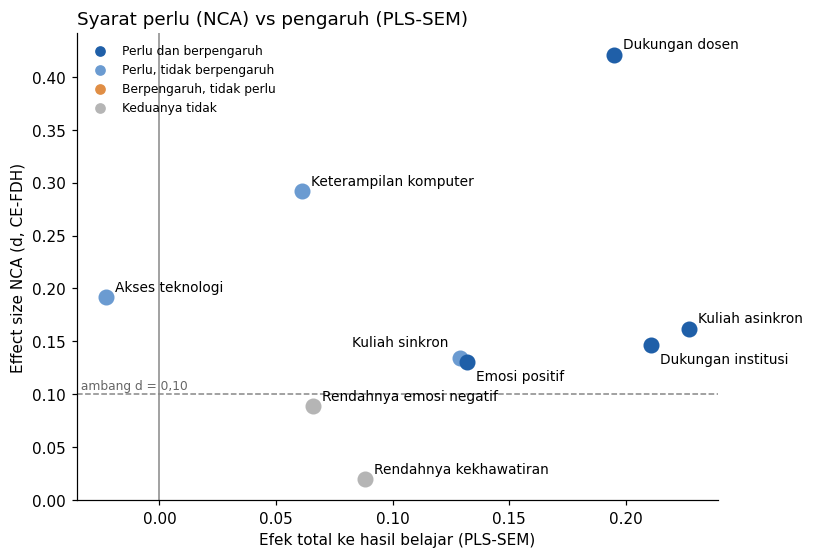

In [17]:
# Peta 2 dimensi: efek total (PLS) vs effect size NCA
fig, ax = plt.subplots(figsize=(7.5, 5.2))
col = {'Perlu dan berpengaruh':'#1f5fa8','Perlu, tidak berpengaruh':'#6b9bd1','Berpengaruh, tidak perlu':'#e08e45','Keduanya tidak':'#b5b5b5'}
for _, r in tab_sum.iterrows():
    ax.scatter(r['Efek total'], r['d NCA'], s=90, color=col[r.Kelompok], zorder=3)
    off = {'SCO': (-8, 8), 'PAE': (6, -12), 'AS': (6, -12)}.get(r.Faktor, (6, 4))
    ax.annotate(r.Nama, (r['Efek total'], r['d NCA']), xytext=off, textcoords='offset points', fontsize=9,
                ha='right' if off[0] < 0 else 'left')
ax.axhline(0.1, color='#888', lw=1, ls='--'); ax.axvline(0, color='#888', lw=1)
ax.text(ax.get_xlim()[0], 0.105, ' ambang d = 0,10', fontsize=8, color='#666')
ax.set_xlabel('Efek total ke hasil belajar (PLS-SEM)'); ax.set_ylabel('Effect size NCA (d, CE-FDH)')
ax.set_title('Syarat perlu (NCA) vs pengaruh (PLS-SEM)', loc='left')
for k_, c_ in col.items(): ax.scatter([], [], color=c_, label=k_)
ax.legend(frameon=False, fontsize=8, loc='upper left')
for s_ in ['top', 'right']: ax.spines[s_].set_visible(False)
plt.tight_layout(); plt.savefig('Gambar_Peta_NCA_PLS.png', dpi=200); plt.show()

## 6b. Pemeriksaan tambahan (asumsi, data hilang, bias metode, ukuran sampel)

1. **Statistik deskriptif dan distribusi**: rata-rata, SD, *skewness*, dan *excess kurtosis* tiap konstruk. PLS-SEM tidak mensyaratkan normalitas, tetapi distribusi tetap dilaporkan (Hair dkk., 2022).
2. **Bias data hilang**: responden lengkap (n = 209) dibandingkan dengan responden Indonesia yang tidak lengkap, pada konstruk yang sempat mereka jawab.
3. ***Common method bias***: *full collinearity* VIF; nilai ≤ 3,3 menunjukkan model bebas bias metode umum (Kock, 2015).
4. **Kecukupan sampel**: metode *inverse square root* (Kock & Hadaya, 2018), n minimum = (2,486 / |β|)² untuk α = 5% dan power 80%.

In [18]:
# 6b.1 Deskriptif konstruk (skor rata-rata butir, skala 1-5)
desc = []
for k, v in BLOCKS.items():
    sc = df[v].mean(axis=1)
    it_sk = df[v].apply(lambda c: stats.skew(c)).abs().max()
    it_ku = df[v].apply(lambda c: stats.kurtosis(c)).abs().max()
    desc.append({'Konstruk': k, 'Nama': LABEL[k], 'M': round(sc.mean(), 2), 'SD': round(sc.std(ddof=1), 2),
                 'Skewness': round(stats.skew(sc), 2), 'Kurtosis': round(stats.kurtosis(sc), 2),
                 '|Skew| butir maks': round(it_sk, 2), '|Kurt| butir maks': round(it_ku, 2)})
tab_desc = pd.DataFrame(desc)
print('Semua |skewness| dan |kurtosis| butir < 2?', bool((tab_desc['|Skew| butir maks'] < 2).all() and (tab_desc['|Kurt| butir maks'] < 2).all()))
tab_desc

Semua |skewness| dan |kurtosis| butir < 2? True


,Konstruk,Nama,M,SD,Skewness,Kurtosis,|Skew| butir maks,|Kurt| butir maks
0,TS,Dukungan dosen,3.44,0.62,-0.39,2.06,0.57,0.99
1,AS,Dukungan institusi,2.98,0.68,0.16,0.87,0.21,0.71
2,SCO,Kuliah sinkron,2.93,0.84,-0.01,-0.20,0.23,0.28
3,ACO,Kuliah asinkron,3.04,0.80,-0.21,0.07,0.20,0.45
4,LT,Akses teknologi,3.42,0.96,-0.13,-0.50,0.79,1.28
5,CS,Keterampilan komputer,3.39,0.65,-0.50,1.80,0.68,1.17
6,WOR,Kekhawatiran hidup,2.99,0.95,0.01,-0.28,0.26,0.87
7,PAE,Emosi positif,3.04,0.85,-0.18,0.26,0.10,0.57
8,NAE,Emosi negatif,3.01,0.83,-0.05,-0.02,0.26,0.44
9,LO,Hasil belajar,2.93,0.69,-0.42,0.35,0.46,0.41


In [19]:
# 6b.2 Responden lengkap vs tidak lengkap (Indonesia)
inc = raw.loc[~raw.index.isin(raw.dropna(subset=ITEMS).index)]
rows = []
for k, v in BLOCKS.items():
    a = df[v].mean(axis=1)
    b = inc[v].dropna().mean(axis=1)
    if len(b) < 10: continue
    t, p = stats.ttest_ind(a, b, equal_var=False)
    sp = np.sqrt(((len(a)-1)*a.var() + (len(b)-1)*b.var()) / (len(a)+len(b)-2))
    rows.append({'Konstruk': k, 'n lengkap': len(a), 'M lengkap': round(a.mean(), 2), 'n tidak lengkap': len(b),
                 'M tidak lengkap': round(b.mean(), 2), 'd': round((a.mean()-b.mean())/sp, 2), 'p': round(p, 3)})
tab_miss = pd.DataFrame(rows)
g1 = df.Q8.isin([1, 2]); g2 = inc.Q8.isin([1, 2])
ct = pd.crosstab(np.r_[np.ones(g1.sum()), np.zeros(g2.sum())], np.r_[df.Q8[g1], inc.Q8[g2]])
chi2, pchi, dof, _ = stats.chi2_contingency(ct)
print(f'Jenis kelamin lengkap vs tidak lengkap: chi2({dof}) = {chi2:.2f}, p = {pchi:.3f}')
print('|d| maksimum:', tab_miss.d.abs().max())
tab_miss

Jenis kelamin lengkap vs tidak lengkap: chi2(1) = 0.28, p = 0.597
|d| maksimum: 0.26


,Konstruk,n lengkap,M lengkap,n tidak lengkap,M tidak lengkap,d,p
0,TS,209,3.44,186,3.34,0.15,0.137
1,AS,209,2.98,111,2.97,0.02,0.879
2,SCO,209,2.93,113,2.96,-0.05,0.689
3,ACO,209,3.04,147,3.07,-0.04,0.711
4,LT,209,3.42,163,3.44,-0.02,0.835
5,CS,209,3.39,159,3.26,0.21,0.050
6,WOR,209,2.99,228,3.13,-0.14,0.148
7,PAE,209,3.04,235,3.02,0.02,0.811
8,NAE,209,3.01,232,2.80,0.26,0.007
9,LO,209,2.93,172,3.01,-0.12,0.249


In [20]:
# 6b.3 Full collinearity VIF (Kock, 2015)
Ylv = res['Y']
fc = {}
for k in LVS:
    others = [q for q in LVS if q != k]
    P = np.column_stack([np.ones(len(Ylv)), Ylv[others].values])
    b = np.linalg.lstsq(P, Ylv[k].values, rcond=None)[0]
    r2 = 1 - np.sum((Ylv[k].values - P @ b) ** 2) / np.sum((Ylv[k].values - Ylv[k].mean()) ** 2)
    fc[k] = round(1 / (1 - r2), 2)
tab_fcvif = pd.DataFrame({'Konstruk': list(fc), 'Full collinearity VIF': list(fc.values())})
print('VIF maksimum:', max(fc.values()), '->', 'bebas CMB (<= 3,3)' if max(fc.values()) <= 3.3 else 'periksa CMB')
tab_fcvif.T

VIF maksimum: 1.7 -> bebas CMB (<= 3,3)


,0,1,2,3,4,5,6,7,8,9
Konstruk,TS,AS,SCO,ACO,LT,CS,WOR,PAE,NAE,LO
Full collinearity VIF,1.45,1.64,1.61,1.68,1.57,1.7,1.21,1.19,1.14,1.55


In [21]:
# 6b.4 Kecukupan sampel: inverse square root method (Kock & Hadaya, 2018)
sig = tab_path[tab_path.Signifikan == 'Ya'].copy()
sig['n minimum'] = np.ceil((2.486 / sig.Koefisien.abs()) ** 2).astype(int)
sig['Cukup (n = %d)?' % len(df)] = np.where(sig['n minimum'] <= len(df), 'Ya', 'Tidak')
tab_nmin = sig[['Jalur', 'Koefisien', 'n minimum', 'Cukup (n = %d)?' % len(df)]]
tab_nmin

,Jalur,Koefisien,n minimum,Cukup (n = 209)?
4,LT->PAE,0.265,89,Ya
9,SCO->NAE,-0.223,125,Ya
11,LT->NAE,0.212,138,Ya
13,WOR->NAE,0.220,128,Ya
14,TS->LO,0.197,160,Ya
15,AS->LO,0.203,150,Ya
17,ACO->LO,0.216,133,Ya
21,PAE->LO,0.132,355,Tidak


## 7. Validasi implementasi

Karena PLS-SEM dan NCA di notebook ini ditulis sendiri, bagian ini memeriksa bahwa hasilnya benar:

1. **Uji NCA dengan contoh hitung manual.** Dua data kecil yang jawabannya bisa dihitung dengan tangan.
2. **PLS-SEM dibandingkan dengan paket independen `plspm`** (Python). Pasang dulu sekali saja: `pip install plspm`. Bila paketnya belum terpasang, sel ini hanya menampilkan pesan dan analisis lain tetap berjalan.
3. **Catatan versi** Python dan paket, untuk dilaporkan di naskah.

In [22]:
# 7.1 NCA: contoh hitung manual
# Contoh A: titik (0,0), (1,1), (2,2). Ruang lingkup = 2x2 = 4.
# Zona kosong di atas plafon CE-FDH = 1x2 + 1x1 = 3  ->  d = 3/4 = 0,75
dA = nca(np.array([0, 1, 2.]), np.array([0, 1, 2.]))
# Contoh B: keempat sudut terisi, termasuk kiri-atas (0,2)  ->  tidak ada zona kosong, d = 0
dB = nca(np.array([0, 0, 2, 2.]), np.array([0, 2, 0, 2.]))
print(f'Contoh A: d = {dA:.3f} (harus 0,750)')
print(f'Contoh B: d = {dB:.3f} (harus 0,000)')
assert abs(dA - 0.75) < 1e-9 and abs(dB) < 1e-9
print('Uji NCA LULUS')

Contoh A: d = 0.750 (harus 0,750)
Contoh B: d = 0.000 (harus 0,000)
Uji NCA LULUS


In [23]:
# 7.2 PLS-SEM: bandingkan dengan paket plspm
try:
    import plspm.config as c
    from plspm.plspm import Plspm
    from plspm.scheme import Scheme
    from plspm.mode import Mode
    order = LVS  # TS, AS, SCO, ACO, LT, CS, WOR, PAE, NAE, LO (eksogen dulu)
    pm = pd.DataFrame(0, index=order, columns=order)
    for e, ps in PATHS.items():
        for p in ps: pm.loc[e, p] = 1
    cfg = c.Config(pm, scaled=True)
    for k, v in BLOCKS.items():
        cfg.add_lv(k, Mode.A, *[c.MV(i) for i in v])
    ref = Plspm(df[ITEMS], cfg, Scheme.PATH)
    pc = ref.path_coefficients()
    rows = []
    for (p, e), b in res['beta'].items():
        rows.append({'Jalur': f'{p}->{e}', 'Notebook': round(b, 4), 'plspm': round(float(pc.loc[e, p]), 4)})
    cmp_ = pd.DataFrame(rows); cmp_['Selisih'] = (cmp_.Notebook - cmp_.plspm).abs().round(4)
    print('Selisih maksimum:', cmp_.Selisih.max(), '-> LULUS' if cmp_.Selisih.max() < 0.005 else '-> PERIKSA')
    display(cmp_)
except ImportError:
    print('Paket plspm belum terpasang. Jalankan:  pip install plspm  lalu ulangi sel ini.')
except Exception as e:
    print('plspm terpasang, tetapi versinya memakai perintah yang berbeda:', repr(e))
    print('Kirim pesan galat ini ke asisten untuk disesuaikan.')

Paket plspm belum terpasang. Jalankan:  pip install plspm  lalu ulangi sel ini.


In [24]:
# 7.3 Versi perangkat lunak (dilaporkan di bagian Metode)
import sys, scipy, matplotlib
print('Python', sys.version.split()[0], '| numpy', np.__version__, '| pandas', pd.__version__,
      '| scipy', scipy.__version__, '| matplotlib', matplotlib.__version__)

Python 3.11.15 | numpy 2.4.4 | pandas 3.0.2 | scipy 1.17.1 | matplotlib 3.10.9


In [25]:
# 7.4 Simpan ringkasan validasi ke folder kerja (untuk bagian Metode naskah)
import sys, scipy, matplotlib, datetime
baris = ['Tanggal: ' + datetime.datetime.now().strftime('%Y-%m-%d %H:%M'),
         f'Python {sys.version.split()[0]} | numpy {np.__version__} | pandas {pd.__version__} | scipy {scipy.__version__} | matplotlib {matplotlib.__version__}',
         f'Uji NCA manual: contoh A d = {dA:.3f} (target 0,750); contoh B d = {dB:.3f} (target 0,000)']
if 'cmp_' in globals():
    baris.append(f'Selisih maksimum koefisien jalur notebook vs plspm: {cmp_.Selisih.max():.4f}')
    cmp_.to_excel('Validasi_plspm.xlsx', index=False)
else:
    baris.append('plspm: belum berhasil dijalankan (lihat pesan di sel 7.2)')
with open('Validasi_Notebook.txt', 'w', encoding='utf-8') as f: f.write('\n'.join(baris))
print('\n'.join(baris)); print('Tersimpan di:', os.getcwd())

Tanggal: 2026-09-29 13:40
Python 3.11.15 | numpy 2.4.4 | pandas 3.0.2 | scipy 1.17.1 | matplotlib 3.10.9
Uji NCA manual: contoh A d = 0.750 (target 0,750); contoh B d = 0.000 (target 0,000)
plspm: belum berhasil dijalankan (lihat pesan di sel 7.2)
Tersimpan di: /tmp/claude-0/nb/work


## 8. Ekspor tabel

Semua tabel disimpan ke `Hasil_Analisis_NCA_PLS.xlsx` agar bisa langsung disalin ke naskah.

In [26]:
with pd.ExcelWriter('Hasil_Analisis_NCA_PLS.xlsx') as w:
    prof.to_excel(w, sheet_name='1_Profil')
    tab_loading.to_excel(w, sheet_name='2_Loading', index=False)
    tab_rel.to_excel(w, sheet_name='3_Reliabilitas', index=False)
    tab_htmt.to_excel(w, sheet_name='4_HTMT')
    tab_fl.to_excel(w, sheet_name='5_FornellLarcker')
    tab_path.to_excel(w, sheet_name='6_Jalur', index=False)
    tab_ind.to_excel(w, sheet_name='7_TidakLangsung', index=False)
    pd.concat([tab_r2]).to_excel(w, sheet_name='8_R2', index=False)
    tab_f2.to_excel(w, sheet_name='9_f2_VIF', index=False)
    tab_q2.to_excel(w, sheet_name='10_Q2predict', index=False)
    tab_nca.to_excel(w, sheet_name='11_NCA', index=False)
    tab_bn.to_excel(w, sheet_name='12_Bottleneck', index=False)
    tab_sum.to_excel(w, sheet_name='13_Ringkasan', index=False)
    tab_desc.to_excel(w, sheet_name='14_Deskriptif', index=False)
    tab_miss.to_excel(w, sheet_name='15_DataHilang', index=False)
    tab_fcvif.to_excel(w, sheet_name='16_FullCollinearityVIF', index=False)
    tab_nmin.to_excel(w, sheet_name='17_UkuranSampel', index=False)
print('Tersimpan: Hasil_Analisis_NCA_PLS.xlsx')

Tersimpan: Hasil_Analisis_NCA_PLS.xlsx


## Referensi metode

- Dul, J. (2016). Necessary Condition Analysis (NCA): Logic and methodology of "necessary but not sufficient" causality. *Organizational Research Methods, 19*(1), 10–52.
- Dul, J., van der Laan, E., & Kuik, R. (2020). A statistical significance test for Necessary Condition Analysis. *Organizational Research Methods, 23*(2), 385–395.
- Hair, J. F., Hult, G. T. M., Ringle, C. M., & Sarstedt, M. (2022). *A primer on partial least squares structural equation modeling (PLS-SEM)* (3rd ed.). Sage.
- Richter, N. F., Schubring, S., Hauff, S., Ringle, C. M., & Sarstedt, M. (2020). When predictors of outcomes are necessary: Guidelines for the combined use of PLS-SEM and NCA. *Industrial Management & Data Systems, 120*(12), 2243–2267.
- Aristovnik, A., dkk. (2021). *Data in Brief, 39*, 107659.
- Zou, Y., & Zou, C. (2024). *Education and Information Technologies, 29*, 6005–6035.